# 6.25 - Benchmark result tables and manifoldness plots

Load the final benchmark result files into one combined dataframe. Later cells will add validity-distance plots and manifoldness tables.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))


pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

RESULTS_DIR = ROOT / 'results'
RESULTS_DIR

PosixPath('/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/results')

## Result Files

In [2]:
RESULT_FILES = {
    'main_l1_baselines': RESULTS_DIR / 'benchmark_full_reduced5000_L1.parquet',
    'certcf_reduced10000_l1': RESULTS_DIR / 'benchmark_full_reduced10000_L1.parquet',
    'face_german_credit': RESULTS_DIR / 'benchmark_face_german_credit.parquet',
    'face_compas': RESULTS_DIR / 'benchmark_face_compas.parquet',
    'face_wisconsin_breast_cancer': RESULTS_DIR / 'benchmark_face_wisconsin_breast_cancer.parquet',
    'face_give_me_some_credit': RESULTS_DIR / 'benchmark_face_give_me_some_credit.parquet',
    'face_lending_club': RESULTS_DIR / 'benchmark_face_lending_club.parquet',
    'face_heloc': RESULTS_DIR / 'benchmark_face_heloc.parquet',
}

EXCLUDED_METHODS_BY_RESULT_KEY = {
    'main_l1_baselines': {'certcf'},
}

FILE_STATUS_DF = pd.DataFrame([
    {
        'result_key': key,
        'path': str(path),
        'available': path.exists(),
        'size_mb': path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
        'excluded_methods': ', '.join(sorted(EXCLUDED_METHODS_BY_RESULT_KEY.get(key, []))),
    }
    for key, path in RESULT_FILES.items()
])

display(FILE_STATUS_DF)

missing = FILE_STATUS_DF.loc[~FILE_STATUS_DF['available'], 'path'].tolist()
if missing:
    raise FileNotFoundError('Missing benchmark result files:\n' + '\n'.join(missing))

,result_key,path,available,size_mb,excluded_methods
0,main_l1_baselines,/home/gabrielepintus/Documents/github/Preimage...,True,7.413036,certcf
1,certcf_reduced10000_l1,/home/gabrielepintus/Documents/github/Preimage...,True,6.478159,
2,face_german_credit,/home/gabrielepintus/Documents/github/Preimage...,True,0.112864,
3,face_compas,/home/gabrielepintus/Documents/github/Preimage...,True,0.097081,
4,face_wisconsin_breast_cancer,/home/gabrielepintus/Documents/github/Preimage...,True,0.087966,
5,face_give_me_some_credit,/home/gabrielepintus/Documents/github/Preimage...,True,0.143084,
6,face_lending_club,/home/gabrielepintus/Documents/github/Preimage...,True,0.148391,
7,face_heloc,/home/gabrielepintus/Documents/github/Preimage...,True,0.170899,


## Load And Combine

In [3]:
frames = []

for result_key, path in RESULT_FILES.items():
    frame = pd.read_parquet(path).copy()
    excluded_methods = EXCLUDED_METHODS_BY_RESULT_KEY.get(result_key, set())
    if excluded_methods:
        frame = frame[~frame['method'].astype(str).isin(excluded_methods)].copy()
    frame['result_key'] = result_key
    frame['result_file'] = path.name
    if 'run_name' not in frame.columns:
        frame['run_name'] = frame['method'].astype(str)
    frames.append(frame)

BENCHMARK_DF = pd.concat(frames, ignore_index=True)

BENCHMARK_DATA = {
    'df': BENCHMARK_DF,
    'file_status': FILE_STATUS_DF,
    'result_files': RESULT_FILES,
    'datasets': sorted(BENCHMARK_DF['dataset'].dropna().astype(str).unique().tolist()),
    'methods': sorted(BENCHMARK_DF['method'].dropna().astype(str).unique().tolist()),
}

print({
    'rows': int(len(BENCHMARK_DF)),
    'datasets': BENCHMARK_DATA['datasets'],
    'methods': BENCHMARK_DATA['methods'],
    'result_files': int(len(RESULT_FILES)),
})

{'rows': 41957, 'datasets': ['adult', 'compas', 'german_credit', 'give_me_some_credit', 'heloc', 'lending_club', 'wisconsin_breast_cancer'], 'methods': ['certcf', 'dice', 'face', 'growing_spheres', 'nearest_neighbor'], 'result_files': 8}


In [4]:
LOAD_SUMMARY_DF = (
    BENCHMARK_DF
    .groupby(['result_key', 'dataset', 'method', 'run_name'], dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values(['dataset', 'method', 'run_name', 'result_key'], ignore_index=True)
)

display(LOAD_SUMMARY_DF)

,result_key,dataset,method,run_name,rows
0,certcf_reduced10000_l1,adult,certcf,certcf_eps_alpha=0.25,1000
1,certcf_reduced10000_l1,adult,certcf,certcf_eps_alpha=0.45,1000
2,certcf_reduced10000_l1,adult,certcf,certcf_eps_alpha=0.65,1000
3,certcf_reduced10000_l1,adult,certcf,certcf_eps_alpha=0.85,1000
4,certcf_reduced10000_l1,adult,certcf,certcf_eps_alpha=0.99,1000
...,...,...,...,...,...
57,certcf_reduced10000_l1,wisconsin_breast_cancer,certcf,certcf_eps_alpha=0.99,56
58,main_l1_baselines,wisconsin_breast_cancer,dice,dice,56
59,face_wisconsin_breast_cancer,wisconsin_breast_cancer,face,face,56
60,main_l1_baselines,wisconsin_breast_cancer,growing_spheres,gs,56


## Analysis Setup

Normalize method labels and derive compact aggregate tables. CertCF keeps one point per `eps_alpha`, which lets us plot its validity--distance frontier.

In [5]:
METHOD_LABELS = {
    'nearest_neighbor': 'NN',
    'growing_spheres': 'Growing Spheres',
    'dice': 'DiCE',
    'face': 'FACE',
}

DATASET_ORDER = [
    'adult',
    'compas',
    'german_credit',
    'give_me_some_credit',
    'heloc',
    'lending_club',
    'wisconsin_breast_cancer',
]

METHOD_ORDER = [
    'CertCF alpha=0.25',
    'CertCF alpha=0.45',
    'CertCF alpha=0.65',
    'CertCF alpha=0.85',
    'CertCF alpha=0.99',
    'NN',
    'Growing Spheres',
    'DiCE',
    'FACE',
]

PALETTE = {
    'CertCF alpha=0.25': '#0B7285',
    'CertCF alpha=0.45': '#1098AD',
    'CertCF alpha=0.65': '#15AABF',
    'CertCF alpha=0.85': '#22B8CF',
    'CertCF alpha=0.99': '#66D9E8',
    'NN': '#495057',
    'Growing Spheres': '#F08C00',
    'DiCE': '#C92A2A',
    'FACE': '#7048E8',
}


def method_label(row: pd.Series) -> str:
    if row['method'] == 'certcf':
        return str(row['run_name']).replace('certcf_eps_alpha=', 'CertCF alpha=')
    return METHOD_LABELS.get(str(row['method']), str(row['run_name']))


ANALYSIS_DF = BENCHMARK_DF.copy()
ANALYSIS_DF['method_label'] = ANALYSIS_DF.apply(method_label, axis=1)
ANALYSIS_DF['is_certcf'] = ANALYSIS_DF['method'].eq('certcf')
ANALYSIS_DF['eps_alpha'] = pd.to_numeric(
    ANALYSIS_DF['run_name'].astype(str).str.extract(r'eps_alpha=([0-9.]+)', expand=False),
    errors='coerce',
)
ANALYSIS_DF['dataset'] = pd.Categorical(ANALYSIS_DF['dataset'], DATASET_ORDER, ordered=True)
ANALYSIS_DF['method_label'] = pd.Categorical(ANALYSIS_DF['method_label'], METHOD_ORDER, ordered=True)
ANALYSIS_DF = ANALYSIS_DF.sort_values(['dataset', 'method_label', 'query_idx'], ignore_index=True)

print({
    'rows': int(len(ANALYSIS_DF)),
    'datasets': int(ANALYSIS_DF['dataset'].nunique()),
    'method_variants': int(ANALYSIS_DF['method_label'].nunique()),
})

{'rows': 41957, 'datasets': 7, 'method_variants': 9}


## Aggregate Summary

This is the main working table for validity--distance and resource comparisons.

In [6]:
def summarize_methods(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset, method_label), group in df.groupby(['dataset', 'method_label'], observed=True, dropna=False):
        success_group = group[group['success']]
        rows.append({
            'dataset': dataset,
            'method_label': method_label,
            'method': group['method'].iloc[0],
            'run_name': group['run_name'].iloc[0],
            'n': int(len(group)),
            'n_valid': int(group['success'].sum()),
            'validity_pct': float(100.0 * group['success'].mean()),
            'l1_mean': float(success_group['l1_distance'].mean()) if len(success_group) else np.nan,
            'l1_median': float(success_group['l1_distance'].median()) if len(success_group) else np.nan,
            'mad_l1_mean': float(success_group['mad_l1_distance'].mean()) if len(success_group) else np.nan,
            'l2_mean': float(success_group['l2_distance'].mean()) if len(success_group) else np.nan,
            'sparsity_mean': float(success_group['l0_sparsity'].mean()) if len(success_group) else np.nan,
            'runtime_mean_s': float(group['runtime_s'].mean()),
            'runtime_median_s': float(group['runtime_s'].median()),
            'build_time_s': float(group['build_time_s'].iloc[0]),
            'ram_peak_mb': float(group['method_meta__ram_rss_mb_peak'].iloc[0]) if 'method_meta__ram_rss_mb_peak' in group.columns else np.nan,
        })
    out = pd.DataFrame(rows)
    out['dataset'] = pd.Categorical(out['dataset'], DATASET_ORDER, ordered=True)
    out['method_label'] = pd.Categorical(out['method_label'], METHOD_ORDER, ordered=True)
    return out.sort_values(['dataset', 'method_label'], ignore_index=True)


SUMMARY_DF = summarize_methods(ANALYSIS_DF)
display(SUMMARY_DF.round(4))

,dataset,method_label,method,run_name,n,n_valid,validity_pct,l1_mean,l1_median,mad_l1_mean,l2_mean,sparsity_mean,runtime_mean_s,runtime_median_s,build_time_s,ram_peak_mb
0,adult,CertCF alpha=0.25,certcf,certcf_eps_alpha=0.25,1000,1000,100.0000,5.3330,5.1583,0.0741,2.3927,0.0573,0.2787,0.1790,294.6410,3140.1211
1,adult,CertCF alpha=0.45,certcf,certcf_eps_alpha=0.45,1000,998,99.8000,6.2687,6.2047,0.0862,2.7102,0.0626,0.5054,0.2347,289.1111,3266.4297
2,adult,CertCF alpha=0.65,certcf,certcf_eps_alpha=0.65,1000,1000,100.0000,7.0818,7.0798,0.0953,2.8556,0.0705,1.0450,0.4395,340.1436,3260.6133
3,adult,CertCF alpha=0.85,certcf,certcf_eps_alpha=0.85,1000,1000,100.0000,7.6869,7.7540,0.1018,2.9461,0.0769,1.7604,0.8337,340.5036,3289.3789
4,adult,CertCF alpha=0.99,certcf,certcf_eps_alpha=0.99,1000,1000,100.0000,7.8769,7.8986,0.1049,2.9926,0.0781,2.0578,0.9192,314.8290,3305.7422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,wisconsin_breast_cancer,CertCF alpha=0.99,certcf,certcf_eps_alpha=0.99,56,56,100.0000,27.4057,24.3675,1.9083,10.1678,0.8077,0.0409,0.0144,6.2822,1695.9102
58,wisconsin_breast_cancer,NN,nearest_neighbor,nn,56,56,100.0000,18.2385,17.0198,1.1753,4.2032,1.0000,0.0000,0.0000,0.0001,1228.0195
59,wisconsin_breast_cancer,Growing Spheres,growing_spheres,gs,56,19,33.9286,3.6473,3.4422,0.2750,1.4491,0.2947,0.0153,0.0151,0.0001,1229.4727
60,wisconsin_breast_cancer,DiCE,dice,dice,56,56,100.0000,8.8229,7.9539,0.5323,3.4707,0.3387,0.7810,0.7810,0.0034,1590.1523


## Validity vs Distance

Lower-right is better: high validity and low distance. CertCF appears as an alpha sweep; baselines are single operating points.

In [7]:
BEST_L1_BY_DATASET_DF = (
    SUMMARY_DF
    .dropna(subset=['l1_mean'])
    .sort_values(['dataset', 'validity_pct', 'l1_mean'], ascending=[True, False, True])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

BEST_MAD_L1_BY_DATASET_DF = (
    SUMMARY_DF
    .dropna(subset=['mad_l1_mean'])
    .sort_values(['dataset', 'validity_pct', 'mad_l1_mean'], ascending=[True, False, True])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

display(
    BEST_L1_BY_DATASET_DF[[
        'dataset', 'method_label', 'validity_pct', 'l1_mean', 'mad_l1_mean', 'runtime_mean_s'
    ]].round(4)
)

display(
    BEST_MAD_L1_BY_DATASET_DF[[
        'dataset', 'method_label', 'validity_pct', 'mad_l1_mean', 'l1_mean', 'runtime_mean_s'
    ]].round(4)
)


,dataset,method_label,validity_pct,l1_mean,mad_l1_mean,runtime_mean_s
0,adult,NN,100.0,4.4856,0.0641,0.0024
1,compas,CertCF alpha=0.45,100.0,1.0716,0.3060,0.0428
2,german_credit,NN,100.0,9.8095,0.1937,0.0001
3,give_me_some_credit,NN,100.0,0.6527,20.6341,0.0014
4,heloc,NN,100.0,9.6318,1.1374,0.0002
5,lending_club,NN,100.0,3.5854,0.2193,0.0007
6,wisconsin_breast_cancer,DiCE,100.0,8.8229,0.5323,0.7810


,dataset,method_label,validity_pct,mad_l1_mean,l1_mean,runtime_mean_s
0,adult,NN,100.0,0.0641,4.4856,0.0024
1,compas,CertCF alpha=0.25,100.0,0.3020,1.0976,0.0357
2,german_credit,NN,100.0,0.1937,9.8095,0.0001
3,give_me_some_credit,NN,100.0,20.6341,0.6527,0.0014
4,heloc,NN,100.0,1.1374,9.6318,0.0002
5,lending_club,NN,100.0,0.2193,3.5854,0.0007
6,wisconsin_breast_cancer,DiCE,100.0,0.5323,8.8229,0.7810


In [8]:
HIGH_VALIDITY_SUMMARY_DF = (
    SUMMARY_DF[SUMMARY_DF['validity_pct'] >= 99.0]
    .sort_values(['dataset', 'method_label'], ignore_index=True)
)

display(
    HIGH_VALIDITY_SUMMARY_DF[[
        'dataset', 'method_label', 'validity_pct', 'l1_mean', 'mad_l1_mean', 'l2_mean', 'runtime_mean_s'
    ]].round(4)
)


,dataset,method_label,validity_pct,l1_mean,mad_l1_mean,l2_mean,runtime_mean_s
0,adult,CertCF alpha=0.25,100.0000,5.3330,0.0741,2.3927,0.2787
1,adult,CertCF alpha=0.45,99.8000,6.2687,0.0862,2.7102,0.5054
2,adult,CertCF alpha=0.65,100.0000,7.0818,0.0953,2.8556,1.0450
3,adult,CertCF alpha=0.85,100.0000,7.6869,0.1018,2.9461,1.7604
4,adult,CertCF alpha=0.99,100.0000,7.8769,0.1049,2.9926,2.0578
5,adult,NN,100.0000,4.4856,0.0641,2.1003,0.0024
6,compas,CertCF alpha=0.25,100.0000,1.0976,0.3020,0.9385,0.0357
7,compas,CertCF alpha=0.45,100.0000,1.0716,0.3060,0.9387,0.0428
8,compas,CertCF alpha=0.65,100.0000,1.0966,0.3155,0.9662,0.0382
9,compas,CertCF alpha=0.85,100.0000,1.1481,0.3272,1.0032,0.0430


## CertCF-Friendly Candidate Tables

These tables test views that may help the paper narrative: best CertCF point at high validity, and resource cost by method.

In [9]:
CERTCF_HIGH_VALIDITY_DF = (
    SUMMARY_DF[SUMMARY_DF['method'].eq('certcf') & (SUMMARY_DF['validity_pct'] >= 99.0)]
    .sort_values(['dataset', 'l1_mean'])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

BASELINE_BEST_DF = (
    SUMMARY_DF[~SUMMARY_DF['method'].eq('certcf')]
    .sort_values(['dataset', 'validity_pct', 'l1_mean'], ascending=[True, False, True])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

CERTCF_VS_BASELINE_DF = CERTCF_HIGH_VALIDITY_DF.merge(
    BASELINE_BEST_DF,
    on='dataset',
    suffixes=('_certcf', '_baseline'),
)
CERTCF_VS_BASELINE_DF['l1_gap_certcf_minus_baseline'] = (
    CERTCF_VS_BASELINE_DF['l1_mean_certcf'] - CERTCF_VS_BASELINE_DF['l1_mean_baseline']
)
CERTCF_VS_BASELINE_DF['validity_gap_certcf_minus_baseline'] = (
    CERTCF_VS_BASELINE_DF['validity_pct_certcf'] - CERTCF_VS_BASELINE_DF['validity_pct_baseline']
)

cols = [
    'dataset',
    'method_label_certcf', 'validity_pct_certcf', 'l1_mean_certcf', 'mad_l1_mean_certcf',
    'method_label_baseline', 'validity_pct_baseline', 'l1_mean_baseline', 'mad_l1_mean_baseline',
    'l1_gap_certcf_minus_baseline', 'validity_gap_certcf_minus_baseline',
]
display(CERTCF_VS_BASELINE_DF[cols].round(4))

,dataset,method_label_certcf,validity_pct_certcf,l1_mean_certcf,mad_l1_mean_certcf,method_label_baseline,validity_pct_baseline,l1_mean_baseline,mad_l1_mean_baseline,l1_gap_certcf_minus_baseline,validity_gap_certcf_minus_baseline
0,adult,CertCF alpha=0.25,100.0,5.3330,0.0741,NN,100.0,4.4856,0.0641,0.8473,0.0
1,compas,CertCF alpha=0.45,100.0,1.0716,0.3060,NN,100.0,1.1706,0.3120,-0.0990,0.0
2,german_credit,CertCF alpha=0.25,100.0,12.3324,0.2373,NN,100.0,9.8095,0.1937,2.5229,0.0
3,give_me_some_credit,CertCF alpha=0.25,100.0,0.6970,30.9339,NN,100.0,0.6527,20.6341,0.0442,0.0
4,heloc,CertCF alpha=0.25,100.0,11.0223,1.3300,NN,100.0,9.6318,1.1374,1.3906,0.0
5,lending_club,CertCF alpha=0.25,100.0,3.6243,0.2253,NN,100.0,3.5854,0.2193,0.0389,0.0
6,wisconsin_breast_cancer,CertCF alpha=0.25,100.0,16.4962,1.0837,DiCE,100.0,8.8229,0.5323,7.6734,0.0


In [10]:
RESOURCE_DF = SUMMARY_DF[[
    'dataset', 'method_label', 'validity_pct', 'build_time_s', 'runtime_mean_s', 'runtime_median_s', 'ram_peak_mb'
]].copy()

display(
    RESOURCE_DF
    .sort_values(['dataset', 'method_label'])
    .round({'validity_pct': 2, 'build_time_s': 3, 'runtime_mean_s': 4, 'runtime_median_s': 4, 'ram_peak_mb': 1})
)

,dataset,method_label,validity_pct,build_time_s,runtime_mean_s,runtime_median_s,ram_peak_mb
0,adult,CertCF alpha=0.25,100.00,294.641,0.2787,0.1790,3140.1
1,adult,CertCF alpha=0.45,99.80,289.111,0.5054,0.2347,3266.4
2,adult,CertCF alpha=0.65,100.00,340.144,1.0450,0.4395,3260.6
3,adult,CertCF alpha=0.85,100.00,340.504,1.7604,0.8337,3289.4
4,adult,CertCF alpha=0.99,100.00,314.829,2.0578,0.9192,3305.7
...,...,...,...,...,...,...,...
57,wisconsin_breast_cancer,CertCF alpha=0.99,100.00,6.282,0.0409,0.0144,1695.9
58,wisconsin_breast_cancer,NN,100.00,0.000,0.0000,0.0000,1228.0
59,wisconsin_breast_cancer,Growing Spheres,33.93,0.000,0.0153,0.0151,1229.5
60,wisconsin_breast_cancer,DiCE,100.00,0.003,0.7810,0.7810,1590.2


## Manifoldness Metrics

Compute average kNN distance and negative LOF score for successful counterfactuals. This cell can be slow because it fits nearest-neighbor and LOF models per dataset.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from counterfactuals.datasets.loaders import (
    AdultDataset,
    CompasDataset,
    GermanCreditDataset,
    GiveMeSomeCreditDataset,
    HELOCDataset,
    LendingClubDataset,
    WisconsinBreastCancerDataset,
)

DATASET_LOADERS = {
    'adult': AdultDataset,
    'compas': CompasDataset,
    'german_credit': GermanCreditDataset,
    'give_me_some_credit': GiveMeSomeCreditDataset,
    'heloc': HELOCDataset,
    'lending_club': LendingClubDataset,
    'wisconsin_breast_cancer': WisconsinBreastCancerDataset,
}


def attach_manifoldness(df: pd.DataFrame, n_knn: int = 5, n_lof: int = 20) -> pd.DataFrame:
    success_df = df[df['success']].copy()
    frames = []
    for dataset_name, dataset_df in success_df.groupby('dataset', observed=True, sort=False):
        loader_cls = DATASET_LOADERS[str(dataset_name)]
        loader = loader_cls(data_dir=str(ROOT / 'data'), seed=42)
        loader.load()
        x_train, _ = loader.get_train()
        n_features = x_train.shape[1]
        cf_cols = [f'x_cf_{i}' for i in range(n_features)]
        x_cf = dataset_df[cf_cols].to_numpy(dtype=np.float32)

        nn = NearestNeighbors(n_neighbors=min(n_knn, len(x_train)), metric='euclidean')
        nn.fit(x_train)
        knn_dist, _ = nn.kneighbors(x_cf)

        lof_neighbors = max(2, min(n_lof, len(x_train) - 1))
        lof = LocalOutlierFactor(n_neighbors=lof_neighbors, novelty=True)
        lof.fit(x_train)
        lof_score = lof.score_samples(x_cf)

        out = dataset_df.copy()
        out['manifold_knn_distance'] = knn_dist.mean(axis=1)
        out['manifold_neg_lof_score'] = -lof_score
        frames.append(out)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


MANIFOLD_DF = attach_manifoldness(ANALYSIS_DF)
MANIFOLDNESS_TABLE_DF = (
    MANIFOLD_DF
    .groupby(['dataset', 'method_label'], observed=True)
    .agg(
        n_success=('success', 'size'),
        avg_knn_distance=('manifold_knn_distance', 'mean'),
        avg_negative_lof_score=('manifold_neg_lof_score', 'mean'),
    )
    .reset_index()
    .sort_values(['dataset', 'method_label'], ignore_index=True)
)

display(MANIFOLDNESS_TABLE_DF.round(4))

Sorted by Average K-NN distance

In [ ]:
MANIFOLDNESS_TABLE_DF.sort_values(['dataset', 'avg_knn_distance'], ascending=[True, True], ignore_index=True)

,dataset,method_label,n_success,avg_knn_distance,avg_negative_lof_score
0,adult,CertCF alpha=0.99,1000,0.307160,1.046958e+00
1,adult,CertCF alpha=0.85,1000,0.314256,1.052056e+00
2,adult,CertCF alpha=0.65,1000,0.461608,1.090065e+00
3,adult,CertCF alpha=0.45,998,0.663883,1.153958e+00
4,adult,CertCF alpha=0.25,1000,0.705765,1.166642e+00
5,adult,NN,1000,0.868972,1.236318e+00
6,adult,Growing Spheres,316,1.179137,1.250821e+00
7,adult,DiCE,898,1.970220,1.646298e+00
8,compas,FACE,614,0.150996,1.978056e+07
9,compas,NN,617,0.180894,2.664285e+07


Sorted by Negative LOF

In [ ]:
MANIFOLDNESS_TABLE_DF.sort_values(['dataset', 'avg_negative_lof_score'], ascending=[True, True], ignore_index=True)

,dataset,method_label,n_success,avg_knn_distance,avg_negative_lof_score
0,adult,CertCF alpha=0.99,1000,0.307160,1.046958e+00
1,adult,CertCF alpha=0.85,1000,0.314256,1.052056e+00
2,adult,CertCF alpha=0.65,1000,0.461608,1.090065e+00
3,adult,CertCF alpha=0.45,998,0.663883,1.153958e+00
4,adult,CertCF alpha=0.25,1000,0.705765,1.166642e+00
5,adult,NN,1000,0.868972,1.236318e+00
6,adult,Growing Spheres,316,1.179137,1.250821e+00
7,adult,DiCE,898,1.970220,1.646298e+00
8,compas,FACE,614,0.150996,1.978056e+07
9,compas,CertCF alpha=0.65,617,0.223084,2.108330e+07


## Target-Class Manifoldness

A more counterfactual-specific on-manifoldness view is to compare each generated counterfactual against the training manifold of its **target class** only. This is often a better diagnostic than using the full mixed train distribution.

In [ ]:
def attach_target_class_manifoldness(df: pd.DataFrame, n_knn: int = 5, n_lof: int = 20) -> pd.DataFrame:
    success_df = df[df['success']].copy()
    frames = []

    for dataset_name, dataset_df in success_df.groupby('dataset', observed=True, sort=False):
        loader_cls = DATASET_LOADERS[str(dataset_name)]
        loader = loader_cls(data_dir=str(ROOT / 'data'), seed=42)
        loader.load()
        x_train, y_train = loader.get_train()
        y_train = y_train.astype(np.int64)
        n_features = x_train.shape[1]
        cf_cols = [f'x_cf_{i}' for i in range(n_features)]

        dataset_frames = []
        for target_class, target_df in dataset_df.groupby('target_class', observed=True, sort=False):
            target_mask = y_train == int(target_class)
            x_ref = x_train[target_mask]
            if len(x_ref) < 2:
                continue

            x_cf = target_df[cf_cols].to_numpy(dtype=np.float32)
            nn = NearestNeighbors(n_neighbors=min(n_knn, len(x_ref)), metric='euclidean')
            nn.fit(x_ref)
            knn_dist, _ = nn.kneighbors(x_cf)

            lof_neighbors = max(2, min(n_lof, len(x_ref) - 1))
            lof = LocalOutlierFactor(n_neighbors=lof_neighbors, novelty=True)
            lof.fit(x_ref)
            lof_score = lof.score_samples(x_cf)

            out = target_df.copy()
            out['target_manifold_knn_distance'] = knn_dist.mean(axis=1)
            out['target_manifold_neg_lof_score'] = -lof_score
            dataset_frames.append(out)

        if dataset_frames:
            frames.append(pd.concat(dataset_frames, ignore_index=True))

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


TARGET_MANIFOLD_DF = attach_target_class_manifoldness(ANALYSIS_DF)
TARGET_MANIFOLDNESS_TABLE_DF = (
    TARGET_MANIFOLD_DF
    .groupby(['dataset', 'method_label'], observed=True)
    .agg(
        n_success=('success', 'size'),
        avg_target_knn_distance=('target_manifold_knn_distance', 'mean'),
        avg_target_negative_lof_score=('target_manifold_neg_lof_score', 'mean'),
    )
    .reset_index()
    .sort_values(['dataset', 'method_label'], ignore_index=True)
)

SUMMARY_WITH_TARGET_MANIFOLD_DF = SUMMARY_DF.merge(
    TARGET_MANIFOLDNESS_TABLE_DF,
    on=['dataset', 'method_label'],
    how='left',
)

display(TARGET_MANIFOLDNESS_TABLE_DF.round(4))

,dataset,method_label,n_success,avg_target_knn_distance,avg_target_negative_lof_score
0,adult,CertCF alpha=0.25,1000,0.9382,1.140400e+00
1,adult,CertCF alpha=0.45,998,0.8410,1.106100e+00
2,adult,CertCF alpha=0.65,1000,0.6262,1.085000e+00
3,adult,CertCF alpha=0.85,1000,0.4607,1.051800e+00
4,adult,CertCF alpha=0.99,1000,0.4440,1.043400e+00
5,adult,NN,1000,1.1358,1.191200e+00
6,adult,Growing Spheres,316,1.4218,1.266100e+00
7,adult,DiCE,898,2.2749,1.509900e+00
8,compas,CertCF alpha=0.25,613,0.2973,1.169400e+00
9,compas,CertCF alpha=0.45,617,0.2935,1.168100e+00


## Privacy Proxy Metrics

For privacy diagnostics, compute how close each successful counterfactual is to the nearest training point. The `dataset_point_proximity_score` is an empirical proximity score, not a literal probability: it is the fraction of training samples whose leave-one-out nearest-neighbor distance is at least as large as the counterfactual's nearest-training distance. Higher values mean the counterfactual looks more like a dataset point under this distance proxy.

In [ ]:
def _nearest_neighbor_reference_scores(x_ref: np.ndarray) -> np.ndarray:
    if len(x_ref) < 2:
        return np.array([], dtype=np.float32)
    nn = NearestNeighbors(n_neighbors=2, metric='euclidean')
    nn.fit(x_ref)
    ref_dist, _ = nn.kneighbors(x_ref)
    return ref_dist[:, 1]


def _empirical_dataset_point_score(
    reference_distances: np.ndarray,
    query_distances: np.ndarray,
    exact_tol: float = 1e-6,
) -> np.ndarray:
    reference_distances = np.sort(np.asarray(reference_distances, dtype=np.float64))
    query_distances = np.asarray(query_distances, dtype=np.float64)
    if len(reference_distances) == 0:
        return np.full_like(query_distances, np.nan, dtype=np.float64)
    query_distances = np.where(query_distances <= exact_tol, 0.0, query_distances)
    # Survival function over train leave-one-out NN distances: high means train-like closeness.
    return (len(reference_distances) - np.searchsorted(reference_distances, query_distances, side='left')) / len(reference_distances)


def attach_privacy_proxies(df: pd.DataFrame, exact_tol: float = 1e-6) -> pd.DataFrame:
    success_df = df[df['success']].copy()
    frames = []

    for dataset_name, dataset_df in success_df.groupby('dataset', observed=True, sort=False):
        loader_cls = DATASET_LOADERS[str(dataset_name)]
        loader = loader_cls(data_dir=str(ROOT / 'data'), seed=42)
        loader.load()
        x_train, y_train = loader.get_train()
        y_train = y_train.astype(np.int64)
        n_features = x_train.shape[1]
        cf_cols = [f'x_cf_{i}' for i in range(n_features)]
        x_cf = dataset_df[cf_cols].to_numpy(dtype=np.float32)

        all_nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
        all_nn.fit(x_train)
        nearest_train_distance, nearest_train_idx = all_nn.kneighbors(x_cf)
        nearest_train_distance = nearest_train_distance[:, 0]
        nearest_train_idx = nearest_train_idx[:, 0]

        all_reference_distances = _nearest_neighbor_reference_scores(x_train)
        out = dataset_df.copy()
        out['nearest_train_distance'] = nearest_train_distance
        out['nearest_train_index'] = nearest_train_idx
        out['nearest_train_label'] = y_train[nearest_train_idx]
        out['nearest_train_is_target'] = out['nearest_train_label'].astype(int) == out['target_class'].astype(int)
        out['exact_train_match'] = out['nearest_train_distance'] <= exact_tol
        out['dataset_point_proximity_score'] = _empirical_dataset_point_score(
            all_reference_distances,
            out['nearest_train_distance'].to_numpy(),
            exact_tol=exact_tol,
        )

        dataset_frames = []
        for target_class, target_df in out.groupby('target_class', observed=True, sort=False):
            target_mask = y_train == int(target_class)
            x_target = x_train[target_mask]
            if len(x_target) == 0:
                continue

            target_cf = target_df[cf_cols].to_numpy(dtype=np.float32)
            target_nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
            target_nn.fit(x_target)
            target_distance, target_idx = target_nn.kneighbors(target_cf)
            target_reference_distances = _nearest_neighbor_reference_scores(x_target)

            target_out = target_df.copy()
            target_out['nearest_target_train_distance'] = target_distance[:, 0]
            target_out['nearest_target_train_index'] = target_idx[:, 0]
            target_out['exact_target_train_match'] = target_out['nearest_target_train_distance'] <= exact_tol
            target_out['target_dataset_point_proximity_score'] = _empirical_dataset_point_score(
                target_reference_distances,
                target_out['nearest_target_train_distance'].to_numpy(),
                exact_tol=exact_tol,
            )
            dataset_frames.append(target_out)

        if dataset_frames:
            frames.append(pd.concat(dataset_frames, ignore_index=True))

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


PRIVACY_PROXY_DF = attach_privacy_proxies(ANALYSIS_DF)
PRIVACY_PROXY_TABLE_DF = (
    PRIVACY_PROXY_DF
    .groupby(['dataset', 'method_label'], observed=True)
    .agg(
        n_success=('success', 'size'),
        avg_nearest_train_distance=('nearest_train_distance', 'mean'),
        median_nearest_train_distance=('nearest_train_distance', 'median'),
        exact_train_match_pct=('exact_train_match', lambda s: 100.0 * s.mean()),
        avg_dataset_point_proximity_score=('dataset_point_proximity_score', 'mean'),
        avg_nearest_target_train_distance=('nearest_target_train_distance', 'mean'),
        median_nearest_target_train_distance=('nearest_target_train_distance', 'median'),
        exact_target_train_match_pct=('exact_target_train_match', lambda s: 100.0 * s.mean()),
        avg_target_dataset_point_proximity_score=('target_dataset_point_proximity_score', 'mean'),
    )
    .reset_index()
    .sort_values(['dataset', 'method_label'], ignore_index=True)
)

SUMMARY_WITH_PRIVACY_DF = SUMMARY_WITH_TARGET_MANIFOLD_DF.merge(
    PRIVACY_PROXY_TABLE_DF,
    on=['dataset', 'method_label'],
    how='left',
)

display(PRIVACY_PROXY_TABLE_DF.round(4))

,dataset,method_label,n_success,avg_nearest_train_distance,median_nearest_train_distance,exact_train_match_pct,avg_dataset_point_proximity_score,avg_nearest_target_train_distance,median_nearest_target_train_distance,exact_target_train_match_pct,avg_target_dataset_point_proximity_score
0,adult,CertCF alpha=0.25,1000,0.1823,0.1410,0.3000,0.8596,0.3554,0.2248,0.3000,0.7850
1,adult,CertCF alpha=0.45,998,0.2771,0.1829,0.2004,0.7934,0.3804,0.2798,0.2004,0.7622
2,adult,CertCF alpha=0.65,1000,0.2083,0.1359,0.2000,0.8455,0.3015,0.2171,0.0000,0.8055
3,adult,CertCF alpha=0.85,1000,0.1485,0.0898,0.2000,0.8929,0.2245,0.1713,0.1000,0.8590
4,adult,CertCF alpha=0.99,1000,0.1592,0.0926,0.2000,0.8908,0.2298,0.1664,0.0000,0.8598
5,adult,NN,1000,0.0000,0.0000,100.0000,1.0000,0.3253,0.0000,66.8000,0.8261
6,adult,Growing Spheres,316,0.9744,0.8902,0.0000,0.4373,1.1780,1.1437,0.0000,0.3975
7,adult,DiCE,898,1.8227,1.7546,0.0000,0.1615,2.0870,2.1043,0.0000,0.1251
8,compas,CertCF alpha=0.25,613,0.0748,0.0495,0.0000,0.4295,0.1412,0.0540,0.0000,0.4585
9,compas,CertCF alpha=0.45,617,0.1209,0.0815,0.0000,0.3750,0.1621,0.0949,0.0000,0.4185


Sorted by the empirical dataset-point proximity score. Higher values indicate stronger train-point similarity and therefore potentially higher privacy leakage under this proxy.

In [ ]:
PRIVACY_PROXY_TABLE_DF.sort_values(
    ['dataset', 'avg_dataset_point_proximity_score', 'avg_nearest_train_distance'],
    ascending=[True, False, True],
    ignore_index=True,
).round(4)

,dataset,method_label,n_success,avg_nearest_train_distance,median_nearest_train_distance,exact_train_match_pct,avg_dataset_point_proximity_score,avg_nearest_target_train_distance,median_nearest_target_train_distance,exact_target_train_match_pct,avg_target_dataset_point_proximity_score
0,adult,NN,1000,0.0000,0.0000,100.0000,1.0000,0.3253,0.0000,66.8000,0.8261
1,adult,CertCF alpha=0.85,1000,0.1485,0.0898,0.2000,0.8929,0.2245,0.1713,0.1000,0.8590
2,adult,CertCF alpha=0.99,1000,0.1592,0.0926,0.2000,0.8908,0.2298,0.1664,0.0000,0.8598
3,adult,CertCF alpha=0.25,1000,0.1823,0.1410,0.3000,0.8596,0.3554,0.2248,0.3000,0.7850
4,adult,CertCF alpha=0.65,1000,0.2083,0.1359,0.2000,0.8455,0.3015,0.2171,0.0000,0.8055
5,adult,CertCF alpha=0.45,998,0.2771,0.1829,0.2004,0.7934,0.3804,0.2798,0.2004,0.7622
6,adult,Growing Spheres,316,0.9744,0.8902,0.0000,0.4373,1.1780,1.1437,0.0000,0.3975
7,adult,DiCE,898,1.8227,1.7546,0.0000,0.1615,2.0870,2.1043,0.0000,0.1251
8,compas,NN,617,0.0000,0.0000,100.0000,1.0000,0.0890,0.0000,69.3679,0.7915
9,compas,FACE,614,0.0000,0.0000,100.0000,1.0000,0.0816,0.0000,68.2410,0.7844


## Exact-Match Privacy And Plausibility Rank

Raw LOF values can be extreme, so this figure separates the two ideas into coordinated panels. The left panel shows exact training-set reuse. The right panel shows each method's within-dataset target-manifold plausibility rank, where rank 1 is best. Faded markers fall below the chosen validity floor.

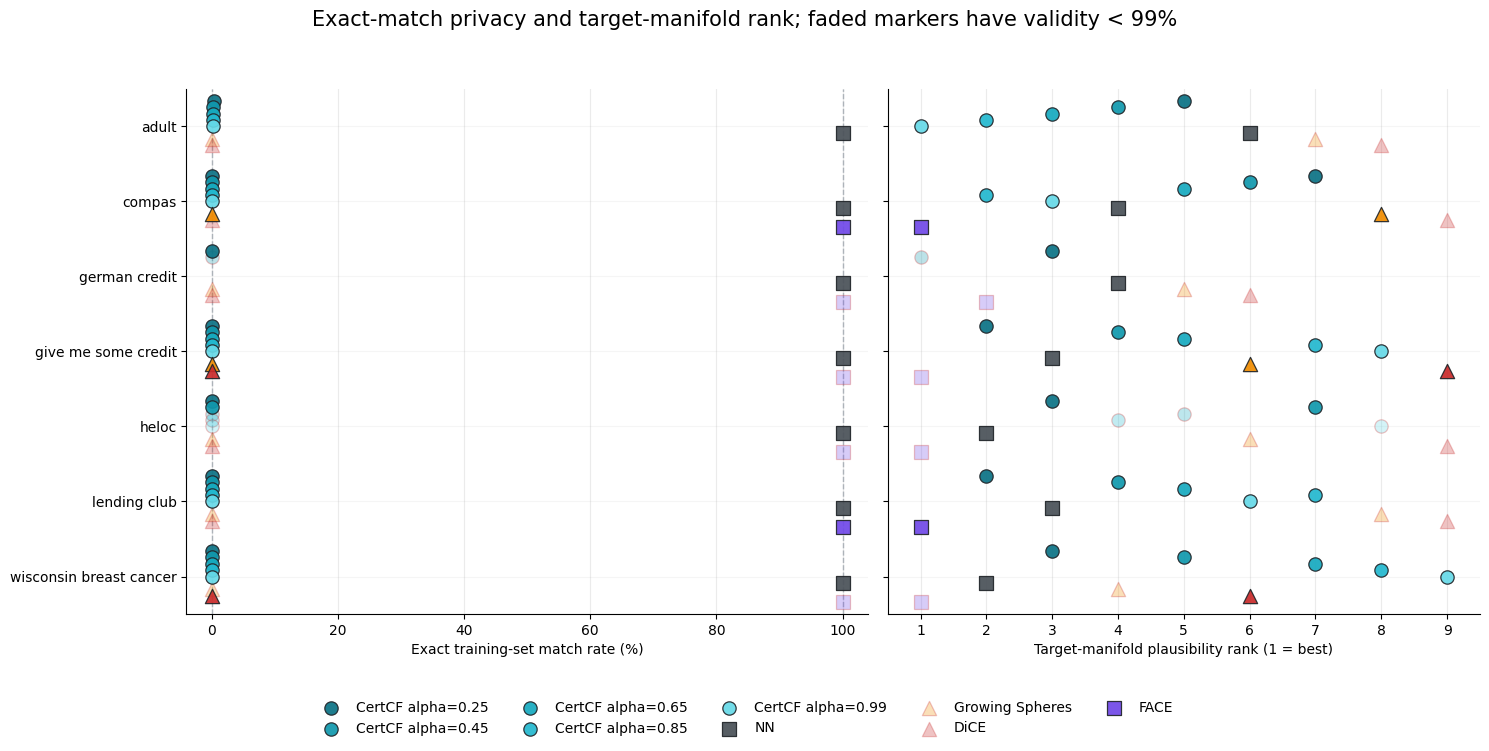

In [ ]:
TRADEOFF_DF = SUMMARY_WITH_PRIVACY_DF.dropna(
    subset=['exact_train_match_pct', 'avg_target_negative_lof_score']
).copy()


def plot_exact_match_and_plausibility_rank(
    df: pd.DataFrame,
    validity_floor: float = 99.0,
    privacy_col: str = 'exact_train_match_pct',
    plausibility_col: str = 'avg_target_negative_lof_score',
):
    plot_df = df.copy()
    if 'eps_alpha' not in plot_df.columns:
        plot_df['eps_alpha'] = pd.to_numeric(
            plot_df['run_name'].astype(str).str.extract(r'eps_alpha=([0-9.]+)', expand=False),
            errors='coerce',
        )
    plot_df = plot_df.dropna(subset=[privacy_col, plausibility_col])
    plot_df['plausibility_rank'] = (
        plot_df.groupby('dataset', observed=True)[plausibility_col]
        .rank(method='min', ascending=True)
        .astype(int)
    )

    method_labels = [m for m in METHOD_ORDER if m in set(plot_df['method_label'].astype(str))]
    offsets = np.linspace(-0.34, 0.34, max(1, len(method_labels)))
    offset_by_method = dict(zip(method_labels, offsets))
    y_by_dataset = {dataset: i for i, dataset in enumerate(DATASET_ORDER)}

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 7.2),
        sharey=True,
        gridspec_kw={'width_ratios': [1.15, 1.0]},
    )

    panels = [
        (axes[0], privacy_col, 'Exact training-set match rate (%)', (-4, 104)),
        (axes[1], 'plausibility_rank', 'Target-manifold plausibility rank (1 = best)', (0.5, plot_df['plausibility_rank'].max() + 0.5)),
    ]

    legend_handles = {}
    for ax, metric_col, xlabel, xlim in panels:
        for _, row in plot_df.iterrows():
            dataset = str(row['dataset'])
            label = str(row['method_label'])
            is_certcf = row['method'] == 'certcf'
            marker = 'o' if is_certcf else ('s' if row['method'] in {'nearest_neighbor', 'face'} else '^')
            color = PALETTE.get(label, '#868E96')
            is_high_validity = row['validity_pct'] >= validity_floor
            y = y_by_dataset[dataset] + offset_by_method.get(label, 0.0)
            point = ax.scatter(
                row[metric_col],
                y,
                s=92 if is_certcf else 105,
                marker=marker,
                color=color,
                edgecolor='#212529' if is_high_validity else '#C92A2A',
                linewidth=0.9,
                alpha=0.92 if is_high_validity else 0.28,
                zorder=3 if is_high_validity else 2,
            )
            legend_handles.setdefault(label, point)

        ax.set_xlabel(xlabel)
        ax.set_xlim(*xlim)
        ax.set_yticks(range(len(DATASET_ORDER)))
        ax.set_yticklabels([d.replace('_', ' ') for d in DATASET_ORDER])
        ax.grid(True, axis='x', alpha=0.25)
        ax.grid(True, axis='y', alpha=0.12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].axvline(0, color='#ADB5BD', linewidth=1.0, linestyle='--', zorder=1)
    axes[0].axvline(100, color='#ADB5BD', linewidth=1.0, linestyle='--', zorder=1)
    axes[1].set_xticks(range(1, int(plot_df['plausibility_rank'].max()) + 1))
    axes[0].set_ylim(len(DATASET_ORDER) - 0.5, -0.5)

    handles = [legend_handles[m] for m in method_labels if m in legend_handles]
    labels = [m for m in method_labels if m in legend_handles]
    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.035),
    )
    fig.suptitle(
        f'Exact-match privacy and target-manifold rank; faded markers have validity < {validity_floor:.0f}%',
        y=0.99,
        fontsize=15,
    )
    fig.tight_layout(rect=(0, 0.07, 1, 0.95))
    return fig


plot_exact_match_and_plausibility_rank(TRADEOFF_DF, validity_floor=99.0);

## CertCF-Friendly Target-Manifold Views

These diagnostics emphasize a stricter question: among methods that already achieve very high validity, which ones stay closest to the target-class data manifold?

In [ ]:
VALIDITY_FLOOR = 100.0

TARGET_LOF_WINNERS_DF = (
    SUMMARY_WITH_TARGET_MANIFOLD_DF[SUMMARY_WITH_TARGET_MANIFOLD_DF['validity_pct'] >= VALIDITY_FLOOR]
    .sort_values(['dataset', 'avg_target_negative_lof_score', 'avg_target_knn_distance'])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

TARGET_LOF_WINNERS_NO_NN_DF = (
    SUMMARY_WITH_TARGET_MANIFOLD_DF[
        (SUMMARY_WITH_TARGET_MANIFOLD_DF['validity_pct'] >= 99.0)
        & (~SUMMARY_WITH_TARGET_MANIFOLD_DF['method'].eq('nearest_neighbor'))
    ]
    .sort_values(['dataset', 'avg_target_negative_lof_score', 'avg_target_knn_distance'])
    .groupby('dataset', observed=True, as_index=False)
    .first()
)

print({
    'certcf_target_lof_wins_at_100_validity': int(TARGET_LOF_WINNERS_DF['method'].eq('certcf').sum()),
    'datasets_compared_at_100_validity': int(len(TARGET_LOF_WINNERS_DF)),
    'certcf_target_lof_wins_at_99_validity_excluding_nn': int(TARGET_LOF_WINNERS_NO_NN_DF['method'].eq('certcf').sum()),
    'datasets_compared_at_99_validity_excluding_nn': int(len(TARGET_LOF_WINNERS_NO_NN_DF)),
})

display(
    TARGET_LOF_WINNERS_DF[[
        'dataset', 'method_label', 'validity_pct', 'avg_target_negative_lof_score', 'avg_target_knn_distance', 'l1_mean'
    ]].round(4)
)

display(
    TARGET_LOF_WINNERS_NO_NN_DF[[
        'dataset', 'method_label', 'validity_pct', 'avg_target_negative_lof_score', 'avg_target_knn_distance', 'l1_mean'
    ]].round(4)
)


{'certcf_target_lof_wins_at_100_validity': 5, 'datasets_compared_at_100_validity': 7, 'certcf_target_lof_wins_at_99_validity_excluding_nn': 5, 'datasets_compared_at_99_validity_excluding_nn': 7}


,dataset,method_label,validity_pct,avg_target_negative_lof_score,avg_target_knn_distance,l1_mean
0,adult,CertCF alpha=0.99,100.0,1.0434,0.4440,7.8769
1,compas,CertCF alpha=0.85,100.0,1.1594,0.2965,1.1481
2,german_credit,CertCF alpha=0.25,100.0,1.0234,2.6615,12.3324
3,give_me_some_credit,CertCF alpha=0.25,100.0,1.0715,0.3372,0.6970
4,heloc,NN,100.0,1.0788,1.5809,9.6318
5,lending_club,CertCF alpha=0.25,100.0,1.0490,0.9942,3.6243
6,wisconsin_breast_cancer,NN,100.0,1.0960,2.0996,18.2385


,dataset,method_label,validity_pct,avg_target_negative_lof_score,avg_target_knn_distance,l1_mean
0,adult,CertCF alpha=0.99,100.0000,1.0434,0.4440,7.8769
1,compas,FACE,99.5138,1.1267,0.2279,1.3977
2,german_credit,CertCF alpha=0.25,100.0000,1.0234,2.6615,12.3324
3,give_me_some_credit,CertCF alpha=0.25,100.0000,1.0715,0.3372,0.6970
4,heloc,CertCF alpha=0.25,100.0000,1.0907,1.6632,11.0223
5,lending_club,FACE,99.0000,1.0332,0.8697,6.8089
6,wisconsin_breast_cancer,CertCF alpha=0.25,100.0000,1.1087,2.4279,16.4962


## Focused Comparison Plots

These comparisons are easier to read than the exploratory scatter grids. For each dataset, we compare the best CertCF configuration against the best competing baseline under the same validity constraint.

,dataset,certcf_label,certcf_validity_pct,certcf_value,certcf_l1_mean,baseline_label,baseline_validity_pct,baseline_value,baseline_l1_mean,certcf_wins,metric_gap_certcf_minus_baseline
0,adult,CertCF alpha=0.99,100.0,1.0434,7.8769,NN,100.0,1.1912,4.4856,True,-0.1478
1,compas,CertCF alpha=0.85,100.0,1.1594,1.1481,NN,100.0,1.1620,1.1706,True,-0.0026
2,german_credit,CertCF alpha=0.25,100.0,1.0234,12.3324,NN,100.0,1.0278,9.8095,True,-0.0044
3,give_me_some_credit,CertCF alpha=0.25,100.0,1.0715,0.6970,NN,100.0,1.0771,0.6527,True,-0.0056
4,heloc,CertCF alpha=0.25,100.0,1.0907,11.0223,NN,100.0,1.0788,9.6318,False,0.0119
5,lending_club,CertCF alpha=0.25,100.0,1.0490,3.6243,NN,100.0,1.0523,3.5854,True,-0.0032
6,wisconsin_breast_cancer,CertCF alpha=0.25,100.0,1.1087,16.4962,NN,100.0,1.0960,18.2385,False,0.0126


,dataset,certcf_label,certcf_validity_pct,certcf_value,certcf_l1_mean,baseline_label,baseline_validity_pct,baseline_value,baseline_l1_mean,certcf_wins,metric_gap_certcf_minus_baseline
0,compas,CertCF alpha=0.85,100.0,1.1594,1.1481,FACE,99.5138,1.1267,1.3977,False,0.0327
1,give_me_some_credit,CertCF alpha=0.25,100.0,1.0715,0.6970,Growing Spheres,99.8000,1.1923,0.2145,True,-0.1208
2,lending_club,CertCF alpha=0.25,100.0,1.0490,3.6243,FACE,99.0000,1.0332,6.8089,False,0.0159
3,wisconsin_breast_cancer,CertCF alpha=0.25,100.0,1.1087,16.4962,DiCE,100.0000,1.3658,8.8229,True,-0.2571


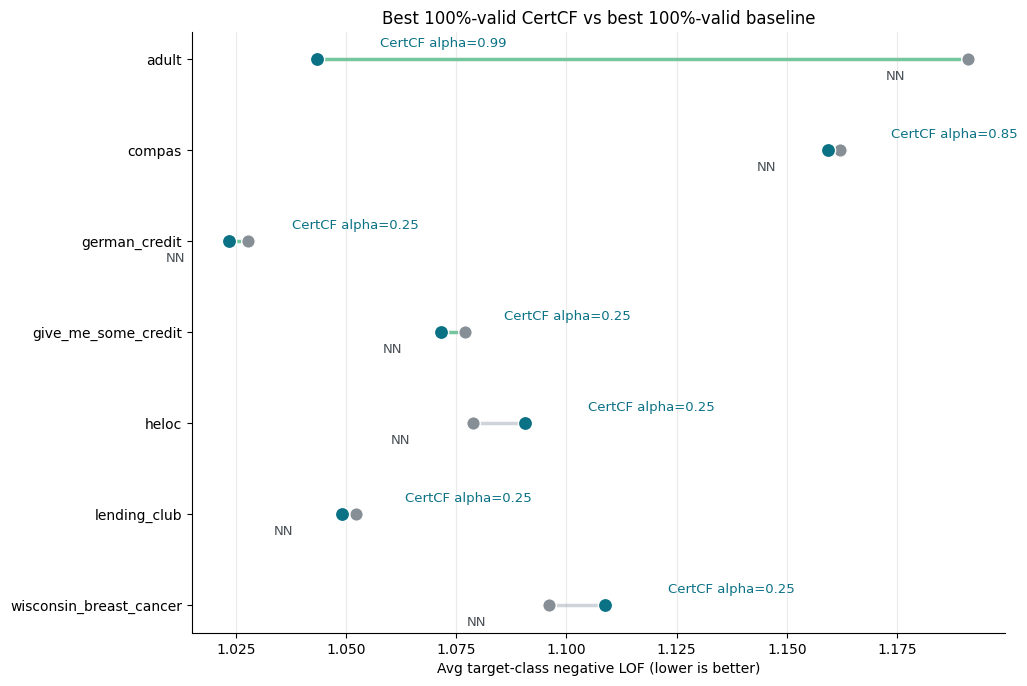

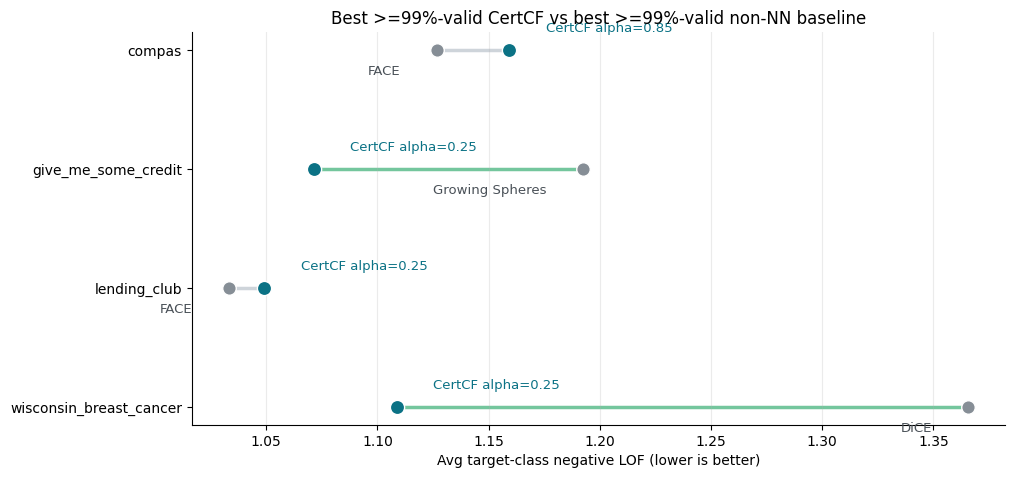

In [ ]:
def build_best_certcf_vs_baseline(
    summary_df: pd.DataFrame,
    metric_col: str,
    validity_floor: float,
    exclude_nn: bool = False,
) -> pd.DataFrame:
    rows = []

    for dataset in DATASET_ORDER:
        ds_df = summary_df[summary_df['dataset'].astype(str).eq(dataset)].copy()
        if ds_df.empty:
            continue

        cert_df = ds_df[
            ds_df['method'].eq('certcf')
            & ds_df['validity_pct'].ge(validity_floor)
            & ds_df[metric_col].notna()
        ].sort_values([metric_col, 'avg_target_knn_distance', 'l1_mean'])

        base_df = ds_df[
            ~ds_df['method'].eq('certcf')
            & ds_df['validity_pct'].ge(validity_floor)
            & ds_df[metric_col].notna()
        ].copy()
        if exclude_nn:
            base_df = base_df[~base_df['method'].eq('nearest_neighbor')]
        base_df = base_df.sort_values([metric_col, 'avg_target_knn_distance', 'l1_mean'])

        if cert_df.empty or base_df.empty:
            continue

        cert_row = cert_df.iloc[0]
        base_row = base_df.iloc[0]
        rows.append({
            'dataset': dataset,
            'certcf_label': cert_row['method_label'],
            'certcf_validity_pct': cert_row['validity_pct'],
            'certcf_value': cert_row[metric_col],
            'certcf_l1_mean': cert_row['l1_mean'],
            'baseline_label': base_row['method_label'],
            'baseline_validity_pct': base_row['validity_pct'],
            'baseline_value': base_row[metric_col],
            'baseline_l1_mean': base_row['l1_mean'],
            'certcf_wins': bool(cert_row[metric_col] < base_row[metric_col]),
            'metric_gap_certcf_minus_baseline': cert_row[metric_col] - base_row[metric_col],
        })

    return pd.DataFrame(rows)


BEST_TARGET_LOF_100_DF = build_best_certcf_vs_baseline(
    SUMMARY_WITH_TARGET_MANIFOLD_DF,
    metric_col='avg_target_negative_lof_score',
    validity_floor=100.0,
    exclude_nn=False,
)

BEST_TARGET_LOF_99_NO_NN_DF = build_best_certcf_vs_baseline(
    SUMMARY_WITH_TARGET_MANIFOLD_DF,
    metric_col='avg_target_negative_lof_score',
    validity_floor=99.0,
    exclude_nn=True,
)

display(BEST_TARGET_LOF_100_DF.round(4))
display(BEST_TARGET_LOF_99_NO_NN_DF.round(4))


def plot_best_comparison_dumbbell(comp_df: pd.DataFrame, title: str, metric_label: str):
    if comp_df.empty:
        raise ValueError('Comparison dataframe is empty.')

    plot_df = comp_df.copy().iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))
    value_max = float(plot_df[['baseline_value', 'certcf_value']].to_numpy().max())
    text_pad = 0.012 * max(1.0, value_max)
    fig_h = max(4.5, 0.9 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(10.5, fig_h))

    for i, row in plot_df.iterrows():
        line_color = '#74C69D' if row['certcf_wins'] else '#CED4DA'
        ax.plot(
            [row['baseline_value'], row['certcf_value']],
            [i, i],
            color=line_color,
            linewidth=2.5,
            solid_capstyle='round',
            zorder=1,
        )
        ax.scatter(row['baseline_value'], i, s=95, color='#868E96', edgecolor='white', linewidth=1.0, zorder=3)
        ax.scatter(row['certcf_value'], i, s=105, color='#0B7285', edgecolor='white', linewidth=1.0, zorder=4)
        ax.text(row['baseline_value'] - text_pad, i - 0.18, str(row['baseline_label']), ha='right', va='center', fontsize=9.5, color='#495057')
        ax.text(row['certcf_value'] + text_pad, i + 0.18, str(row['certcf_label']), ha='left', va='center', fontsize=9.5, color='#0B7285')

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['dataset'])
    ax.set_xlabel(metric_label)
    ax.set_title(title)
    ax.grid(True, axis='x', alpha=0.25)
    ax.grid(False, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return fig


plot_best_comparison_dumbbell(
    BEST_TARGET_LOF_100_DF,
    title='Best 100%-valid CertCF vs best 100%-valid baseline',
    metric_label='Avg target-class negative LOF (lower is better)',
);

plot_best_comparison_dumbbell(
    BEST_TARGET_LOF_99_NO_NN_DF,
    title='Best >=99%-valid CertCF vs best >=99%-valid non-NN baseline',
    metric_label='Avg target-class negative LOF (lower is better)',
);

## Privacy-Validity-Manifold Tradeoff

This section focuses on the clearest CertCF story: under a strict validity floor, how does the best CertCF configuration compare against the best competing baseline on an interpretable privacy proxy and target-manifold plausibility?

{'certcf_joint_wins_exact_privacy_100_validity': 6, 'datasets_compared_exact_privacy_100_validity': 7, 'certcf_joint_wins_exact_privacy_99_validity_excluding_nn': 3, 'datasets_compared_exact_privacy_99_validity_excluding_nn': 4, 'certcf_frontier_points_exact_privacy_100_validity': 7, 'frontier_points_total_exact_privacy_100_validity': 9}


,dataset,certcf_label,certcf_validity_pct,certcf_privacy_value,certcf_plausibility_value,baseline_label,baseline_validity_pct,baseline_privacy_value,baseline_plausibility_value,certcf_privacy_wins,certcf_plausibility_wins,certcf_joint_win
0,adult,CertCF alpha=0.99,100.0,0.2,1.0434,NN,100.0,100.0,1.1912,True,True,True
1,compas,CertCF alpha=0.85,100.0,0.0,1.1594,NN,100.0,100.0,1.1620,True,True,True
2,german_credit,CertCF alpha=0.25,100.0,0.0,1.0234,NN,100.0,100.0,1.0278,True,True,True
3,give_me_some_credit,CertCF alpha=0.25,100.0,0.0,1.0715,NN,100.0,100.0,1.0771,True,True,True
4,heloc,CertCF alpha=0.25,100.0,0.0,1.0907,NN,100.0,100.0,1.0788,True,False,False
5,lending_club,CertCF alpha=0.25,100.0,0.0,1.0490,NN,100.0,100.0,1.0523,True,True,True
6,wisconsin_breast_cancer,CertCF alpha=0.25,100.0,0.0,1.1087,DiCE,100.0,0.0,1.3658,False,True,True


,dataset,certcf_label,certcf_validity_pct,certcf_privacy_value,certcf_plausibility_value,baseline_label,baseline_validity_pct,baseline_privacy_value,baseline_plausibility_value,certcf_privacy_wins,certcf_plausibility_wins,certcf_joint_win
0,compas,CertCF alpha=0.85,100.0,0.0,1.1594,Growing Spheres,99.5138,0.0,1.2801,False,True,True
1,give_me_some_credit,CertCF alpha=0.25,100.0,0.0,1.0715,Growing Spheres,99.8000,0.0,1.1923,False,True,True
2,lending_club,CertCF alpha=0.25,100.0,0.0,1.0490,FACE,99.0000,100.0,1.0332,True,False,False
3,wisconsin_breast_cancer,CertCF alpha=0.25,100.0,0.0,1.1087,DiCE,100.0000,0.0,1.3658,False,True,True


,method_label,frontier_points
0,CertCF alpha=0.25,5
1,NN,2
2,CertCF alpha=0.85,1
3,CertCF alpha=0.99,1


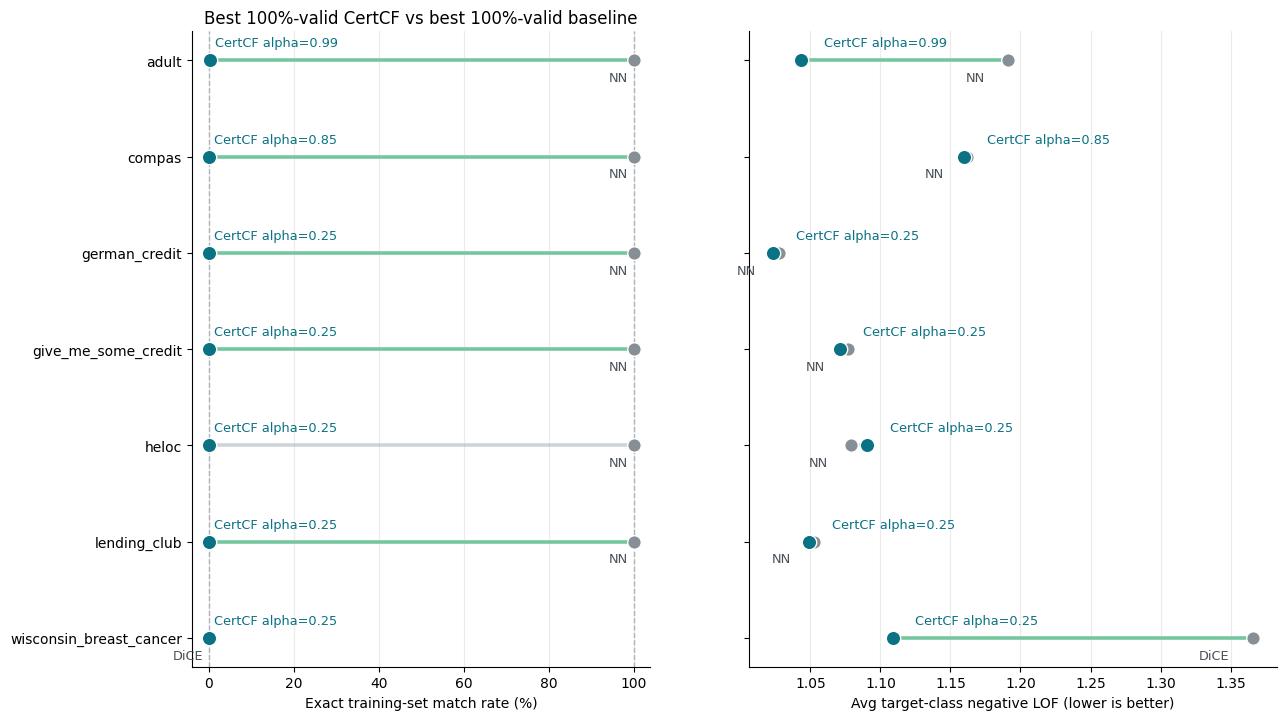

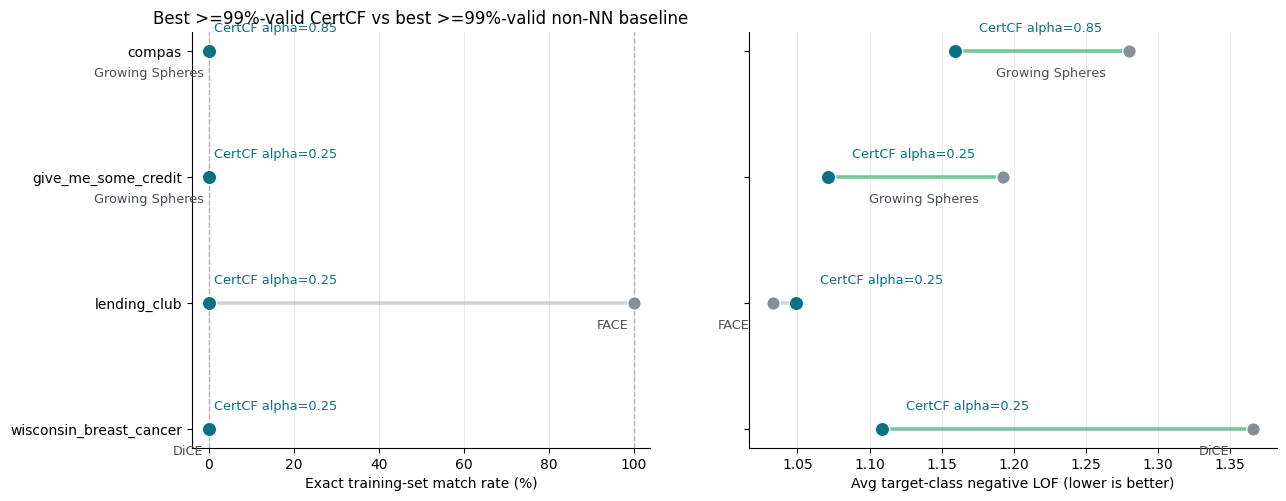

In [ ]:
def build_privacy_tradeoff_df(
    summary_df: pd.DataFrame,
    privacy_col: str = 'exact_train_match_pct',
    plausibility_col: str = 'avg_target_negative_lof_score',
    validity_floor: float = 100.0,
    exclude_nn: bool = False,
) -> pd.DataFrame:
    rows = []

    for dataset in DATASET_ORDER:
        ds_df = summary_df[summary_df['dataset'].astype(str).eq(dataset)].copy()
        if ds_df.empty:
            continue

        cert_df = ds_df[
            ds_df['method'].eq('certcf')
            & ds_df['validity_pct'].ge(validity_floor)
            & ds_df[privacy_col].notna()
            & ds_df[plausibility_col].notna()
        ].sort_values([privacy_col, plausibility_col, 'l1_mean'])

        base_df = ds_df[
            ~ds_df['method'].eq('certcf')
            & ds_df['validity_pct'].ge(validity_floor)
            & ds_df[privacy_col].notna()
            & ds_df[plausibility_col].notna()
        ].copy()
        if exclude_nn:
            base_df = base_df[~base_df['method'].eq('nearest_neighbor')]
        base_df = base_df.sort_values([privacy_col, plausibility_col, 'l1_mean'])

        if cert_df.empty or base_df.empty:
            continue

        cert_row = cert_df.iloc[0]
        base_row = base_df.iloc[0]
        privacy_not_worse = cert_row[privacy_col] <= base_row[privacy_col]
        plausibility_not_worse = cert_row[plausibility_col] <= base_row[plausibility_col]
        strict_improvement = (
            (cert_row[privacy_col] < base_row[privacy_col])
            or (cert_row[plausibility_col] < base_row[plausibility_col])
        )

        rows.append({
            'dataset': dataset,
            'certcf_label': cert_row['method_label'],
            'certcf_validity_pct': cert_row['validity_pct'],
            'certcf_privacy_value': cert_row[privacy_col],
            'certcf_plausibility_value': cert_row[plausibility_col],
            'baseline_label': base_row['method_label'],
            'baseline_validity_pct': base_row['validity_pct'],
            'baseline_privacy_value': base_row[privacy_col],
            'baseline_plausibility_value': base_row[plausibility_col],
            'certcf_privacy_wins': bool(cert_row[privacy_col] < base_row[privacy_col]),
            'certcf_plausibility_wins': bool(cert_row[plausibility_col] < base_row[plausibility_col]),
            'certcf_joint_win': bool(privacy_not_worse and plausibility_not_worse and strict_improvement),
        })

    return pd.DataFrame(rows)


def build_pareto_frontier_df(
    summary_df: pd.DataFrame,
    privacy_col: str = 'exact_train_match_pct',
    plausibility_col: str = 'avg_target_negative_lof_score',
    validity_floor: float = 100.0,
) -> pd.DataFrame:
    frontier_rows = []

    for dataset in DATASET_ORDER:
        ds_df = summary_df[
            summary_df['dataset'].astype(str).eq(dataset)
            & summary_df['validity_pct'].ge(validity_floor)
            & summary_df[privacy_col].notna()
            & summary_df[plausibility_col].notna()
        ].copy()
        if ds_df.empty:
            continue

        values = ds_df[[privacy_col, plausibility_col]].to_numpy(dtype=np.float64)
        efficient = []
        for i, value in enumerate(values):
            dominated = False
            for j, other in enumerate(values):
                if i == j:
                    continue
                if (
                    (other[0] <= value[0])
                    and (other[1] <= value[1])
                    and ((other[0] < value[0]) or (other[1] < value[1]))
                ):
                    dominated = True
                    break
            if not dominated:
                efficient.append(i)

        frontier_rows.append(ds_df.iloc[efficient].copy())

    return pd.concat(frontier_rows, ignore_index=True) if frontier_rows else pd.DataFrame()


EXACT_PRIVACY_TRADEOFF_100_DF = build_privacy_tradeoff_df(
    SUMMARY_WITH_PRIVACY_DF,
    privacy_col='exact_train_match_pct',
    plausibility_col='avg_target_negative_lof_score',
    validity_floor=100.0,
    exclude_nn=False,
)

EXACT_PRIVACY_TRADEOFF_99_NO_NN_DF = build_privacy_tradeoff_df(
    SUMMARY_WITH_PRIVACY_DF,
    privacy_col='exact_train_match_pct',
    plausibility_col='avg_target_negative_lof_score',
    validity_floor=99.0,
    exclude_nn=True,
)

EXACT_PRIVACY_FRONTIER_100_DF = build_pareto_frontier_df(
    SUMMARY_WITH_PRIVACY_DF,
    privacy_col='exact_train_match_pct',
    plausibility_col='avg_target_negative_lof_score',
    validity_floor=100.0,
)

EXACT_PRIVACY_FRONTIER_COUNT_DF = (
    EXACT_PRIVACY_FRONTIER_100_DF
    .groupby(['method_label'], observed=True)
    .size()
    .reset_index(name='frontier_points')
    .sort_values(['frontier_points', 'method_label'], ascending=[False, True], ignore_index=True)
)

print({
    'certcf_joint_wins_exact_privacy_100_validity': int(EXACT_PRIVACY_TRADEOFF_100_DF['certcf_joint_win'].sum()),
    'datasets_compared_exact_privacy_100_validity': int(len(EXACT_PRIVACY_TRADEOFF_100_DF)),
    'certcf_joint_wins_exact_privacy_99_validity_excluding_nn': int(EXACT_PRIVACY_TRADEOFF_99_NO_NN_DF['certcf_joint_win'].sum()),
    'datasets_compared_exact_privacy_99_validity_excluding_nn': int(len(EXACT_PRIVACY_TRADEOFF_99_NO_NN_DF)),
    'certcf_frontier_points_exact_privacy_100_validity': int(EXACT_PRIVACY_FRONTIER_100_DF['method'].eq('certcf').sum()),
    'frontier_points_total_exact_privacy_100_validity': int(len(EXACT_PRIVACY_FRONTIER_100_DF)),
})

display(EXACT_PRIVACY_TRADEOFF_100_DF.round(4))
display(EXACT_PRIVACY_TRADEOFF_99_NO_NN_DF.round(4))
display(EXACT_PRIVACY_FRONTIER_COUNT_DF)


def plot_privacy_plausibility_dumbbell(
    comp_df: pd.DataFrame,
    title: str,
    privacy_label: str = 'Exact training-set match rate (%)',
    plausibility_label: str = 'Avg target-class negative LOF (lower is better)',
):
    if comp_df.empty:
        raise ValueError('Comparison dataframe is empty.')

    plot_df = comp_df.copy().iloc[::-1].reset_index(drop=True)
    y = np.arange(len(plot_df))
    fig_h = max(4.8, 0.95 * len(plot_df) + 1.6)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14.0, fig_h),
        sharey=True,
        gridspec_kw={'width_ratios': [1.0, 1.15]},
    )

    panel_specs = [
        ('baseline_privacy_value', 'certcf_privacy_value', privacy_label),
        ('baseline_plausibility_value', 'certcf_plausibility_value', plausibility_label),
    ]

    for ax, (baseline_col, certcf_col, xlabel) in zip(axes, panel_specs):
        value_max = float(plot_df[[baseline_col, certcf_col]].to_numpy().max())
        text_pad = 0.012 * max(1.0, value_max)

        for i, row in plot_df.iterrows():
            line_color = '#74C69D' if row['certcf_joint_win'] else '#CED4DA'
            ax.plot(
                [row[baseline_col], row[certcf_col]],
                [i, i],
                color=line_color,
                linewidth=2.6,
                solid_capstyle='round',
                zorder=1,
            )
            ax.scatter(row[baseline_col], i, s=95, color='#868E96', edgecolor='white', linewidth=1.0, zorder=3)
            ax.scatter(row[certcf_col], i, s=108, color='#0B7285', edgecolor='white', linewidth=1.0, zorder=4)
            ax.text(row[baseline_col] - text_pad, i - 0.18, str(row['baseline_label']), ha='right', va='center', fontsize=9.3, color='#495057')
            ax.text(row[certcf_col] + text_pad, i + 0.18, str(row['certcf_label']), ha='left', va='center', fontsize=9.3, color='#0B7285')

        ax.set_xlabel(xlabel)
        ax.grid(True, axis='x', alpha=0.25)
        ax.grid(False, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(plot_df['dataset'])
    axes[0].set_xlim(-4, 104)
    axes[0].axvline(0, color='#ADB5BD', linewidth=1.0, linestyle='--', zorder=1)
    axes[0].axvline(100, color='#ADB5BD', linewidth=1.0, linestyle='--', zorder=1)
    axes[0].set_title(title)
    return fig


plot_privacy_plausibility_dumbbell(
    EXACT_PRIVACY_TRADEOFF_100_DF,
    title='Best 100%-valid CertCF vs best 100%-valid baseline',
);

plot_privacy_plausibility_dumbbell(
    EXACT_PRIVACY_TRADEOFF_99_NO_NN_DF,
    title='Best >=99%-valid CertCF vs best >=99%-valid non-NN baseline',
);